# Pipeline d'Inférence d'Images avec TensorFlow
Ce notebook présente un pipeline complet d'inférence d'images à l'aide de TensorFlow et Keras. Il inclut la classification, le débruitage et la génération de légendes.

In [32]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import pickle
from PIL import Image
from typing import List, Tuple, Dict, Optional, Union

## Paramètres globaux

In [ ]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
DATA_DIR = "./dataset_livrable_1"
CLASS_NAMES = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

## Chargement des modèles entraînés

In [ ]:
class CNNEncoder(tf.keras.Model):
    """Encodeur CNN qui transforme les caractéristiques de l'image"""
    def __init__(self, embedding_dim: int, **kwargs):
        super(CNNEncoder, self).__init__(name="cnn_encoder", **kwargs)
        self.embedding_dim = embedding_dim
        self.dense = tf.keras.layers.Dense(embedding_dim, name="encoder_dense")
        self.dropout = tf.keras.layers.Dropout(0.3, name="encoder_dropout")
        self.bn = tf.keras.layers.BatchNormalization(name="encoder_batch_norm")
        
    def call(self, features: tf.Tensor, training: bool = False) -> tf.Tensor:
        """
        Passe avant de l'encodeur
        
        Args:
            features: Caractéristiques de l'image extraites par InceptionV3
            training: Indique si le modèle est en mode entraînement
            
        Returns:
            Caractéristiques transformées
        """
        x = self.dense(features)
        x = self.bn(x, training=training)
        x = tf.nn.relu(x)
        if training:
            x = self.dropout(x)
        return x

In [ ]:
class BahdanauAttention(tf.keras.Model):
    """Mécanisme d'attention de Bahdanau"""
    def __init__(self, units: int):
        super(BahdanauAttention, self).__init__(name="bahdanau_attention")
        self.W1 = tf.keras.layers.Dense(units, name="attention_w1")
        self.W2 = tf.keras.layers.Dense(units, name="attention_w2")
        self.V = tf.keras.layers.Dense(1, name="attention_v")
    
    def call(self, features: tf.Tensor, hidden: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        """
        Calcule les poids d'attention et le vecteur de contexte
        
        Args:
            features: Caractéristiques de l'image encodées
            hidden: État caché du décodeur RNN
            
        Returns:
            Tuple contenant:
            - Vecteur de contexte
            - Poids d'attention
        """
        # Expansion de la dimension temporelle pour l'état caché
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        
        # Calcul du score d'attention
        attention_hidden_layer = tf.nn.tanh(
            self.W1(features) + self.W2(hidden_with_time_axis)
        )
        score = self.V(attention_hidden_layer)
        
        # Normalisation des poids d'attention
        attention_weights = tf.nn.softmax(score, axis=1)
        
        # Calcul du vecteur de contexte
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        
        return context_vector, attention_weights


In [ ]:
class RNNDecoder(tf.keras.Model):
    """Décodeur RNN avec mécanisme d'attention"""
    def __init__(self, embedding_dim: int, units: int, vocab_size: int):
        super(RNNDecoder, self).__init__(name="rnn_decoder")
        self.units = units
        
        # Couches du décodeur
        self.embedding = tf.keras.layers.Embedding(
            vocab_size, embedding_dim, name="decoder_embedding"
        )
        self.gru = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer='glorot_uniform',
            recurrent_dropout=0.1,
            name="decoder_gru"
        )
        self.fc1 = tf.keras.layers.Dense(units, name="decoder_fc1")
        self.dropout = tf.keras.layers.Dropout(0.5, name="decoder_dropout")
        self.fc2 = tf.keras.layers.Dense(vocab_size, name="decoder_output")
        
        # Mécanisme d'attention
        self.attention = BahdanauAttention(units)

    def call(
        self, 
        x: tf.Tensor, 
        features: tf.Tensor, 
        hidden: tf.Tensor, 
        training: bool = False
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """
        Passe avant du décodeur
        
        Args:
            x: Entrée du décodeur (tokens embeddings)
            features: Caractéristiques de l'image encodées
            hidden: État caché précédent
            training: Indique si le modèle est en mode entraînement
            
        Returns:
            Tuple contenant:
            - Prédictions de mots
            - Nouvel état caché
            - Poids d'attention
        """
        # Calcul du vecteur de contexte avec attention
        context_vector, attention_weights = self.attention(features, hidden)
        
        # Conversion des indices en embeddings
        x = self.embedding(x)
        
        # Concaténation du vecteur de contexte et des embeddings
        context_vector_expanded = tf.expand_dims(context_vector, 1)
        x = tf.concat([context_vector_expanded, x], axis=-1)
        
        # Passage par le GRU
        output, state = self.gru(x)
        
        # Reshape de la sortie
        x = self.fc1(output)
        if training:
            x = self.dropout(x)
        x = tf.reshape(x, (-1, x.shape[2]))
        
        # Prédiction du vocabulaire
        x = self.fc2(x)
        
        return x, state, attention_weights

    def initialize_hidden_state(self, batch_size: int) -> tf.Tensor:
        """
        Initialise l'état caché du décodeur
        
        Args:
            batch_size: Taille du batch
            
        Returns:
            État caché initial (zéros)
        """
        return tf.zeros((batch_size, self.units))


In [ ]:
class ImageCaptioningModel:
    """
    Classe pour charger et utiliser un modèle de génération de légendes d'images entraîné
    """
    def __init__(self, model_dir: str = "./saved_models"):
        """
        Initialise le modèle en chargeant les composants nécessaires
        
        Args:
            model_dir: Répertoire contenant les modèles sauvegardés
        """
        self.model_dir = model_dir
        self.encoder = None
        self.decoder = None
        self.feature_extractor = None
        self.tokenizer = None
        self.metadata = None
        self.max_length = None
        self.img_size = None
        
        # Charger les composants du modèle
        self._load_models()
    
    def _load_models(self) -> None:
        """Charge les modèles et métadonnées nécessaires"""
        print("Chargement des modèles et métadonnées...")
        
        # Charger les métadonnées
        metadata_path = os.path.join(self.model_dir, 'model_metadata.json')
        with open(metadata_path, 'r') as f:
            self.metadata = json.load(f)
        
        # Extraire les informations importantes
        self.max_length = self.metadata['max_length']
        self.img_size = tuple(self.metadata['img_size'])
        
        # Charger le tokenizer
        tokenizer_path = os.path.join(self.model_dir, 'tokenizer.pickle')
        with open(tokenizer_path, 'rb') as handle:
            self.tokenizer = pickle.load(handle)
        
        # Charger le modèle encodeur (utilisez best_encoder s'il existe, sinon final_encoder)
        encoder_path = os.path.join(self.model_dir, 'best_encoder.keras')
        if not os.path.exists(encoder_path):
            encoder_path = os.path.join(self.model_dir, 'final_encoder.keras')
        self.encoder = tf.keras.models.load_model(encoder_path, custom_objects={'CNNEncoder': CNNEncoder})
        
        # Charger le modèle décodeur
        decoder_path = os.path.join(self.model_dir, 'best_decoder.keras')
        if not os.path.exists(decoder_path):
            decoder_path = os.path.join(self.model_dir, 'final_decoder.keras')
        self.decoder = tf.keras.models.load_model(decoder_path, custom_objects={
            'RNNDecoder': RNNDecoder,
            'BahdanauAttention': BahdanauAttention
        })
        
        # Créer le modèle d'extraction de caractéristiques
        self._create_feature_extractor()
        
        print("Modèles chargés avec succès!")
    
    def _create_feature_extractor(self) -> None:
        """Crée le modèle d'extraction de caractéristiques InceptionV3"""
        image_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
        self.feature_extractor = tf.keras.Model(
            inputs=image_model.input, 
            outputs=image_model.layers[-1].output
        )
    
    def _load_and_preprocess_image(self, image_path: Union[str, np.ndarray]) -> tf.Tensor:
        """
        Charge et prétraite une image pour l'entrée du modèle
        
        Args:
            image_path: Chemin vers l'image ou array numpy (déjà chargée)
            
        Returns:
            Tenseur de l'image prétraitée
        """
        if isinstance(image_path, str):
            # Charger l'image depuis le fichier
            img = tf.io.read_file(image_path)
            img = tf.image.decode_jpeg(img, channels=3)
        else:
            # Utiliser l'image déjà chargée
            img = tf.convert_to_tensor(image_path)
        
        # Redimensionner et prétraiter
        img = tf.image.resize(img, self.img_size)
        img = tf.keras.applications.inception_v3.preprocess_input(img)
        return img
    
    def extract_features(self, image_path: Union[str, np.ndarray]) -> tf.Tensor:
        """
        Extrait les caractéristiques d'une image
        
        Args:
            image_path: Chemin vers l'image ou array numpy (déjà chargée)
            
        Returns:
            Caractéristiques extraites de l'image
        """
        # Prétraiter l'image
        img = self._load_and_preprocess_image(image_path)
        img_tensor = tf.expand_dims(img, 0)
        
        # Extraire les caractéristiques
        features = self.feature_extractor(img_tensor)
        features = tf.reshape(
            features,
            (features.shape[0], -1, features.shape[3])
        )
        
        return features
    
    def generate_caption(
        self, 
        image_path: Union[str, np.ndarray],
        beam_size: int = 3,
        temperature: float = 1.0,
        return_attention: bool = False
    ) -> Union[str, Tuple[str, np.ndarray]]:
        """
        Génère une légende pour une image
        
        Args:
            image_path: Chemin vers l'image ou array numpy (déjà chargée)
            beam_size: Taille du beam search (1 = greedy search)
            temperature: Contrôle la diversité des prédictions
            return_attention: Si True, retourne également les poids d'attention
            
        Returns:
            Légende générée (et matrice d'attention si return_attention=True)
        """
        # Extraire et encoder les caractéristiques
        features = self.extract_features(image_path)
        encoded_features = self.encoder(features, training=False)
        
        if beam_size <= 1:
            # Utiliser la recherche gloutonne
            return self._greedy_search(encoded_features, temperature, return_attention)
        else:
            # Utiliser beam search
            return self._beam_search(encoded_features, beam_size, temperature, return_attention)
    
    def _greedy_search(
        self, 
        features: tf.Tensor,
        temperature: float = 1.0,
        return_attention: bool = False
    ) -> Union[str, Tuple[str, np.ndarray]]:
        """
        Génère une légende avec une recherche gloutonne
        
        Args:
            features: Caractéristiques encodées de l'image
            temperature: Contrôle la diversité des prédictions
            return_attention: Si True, retourne également les poids d'attention
            
        Returns:
            Légende générée (et matrice d'attention si return_attention=True)
        """
        attention_plot = np.zeros((self.max_length, self.metadata['attention_features_shape']))
        
        # Initialisation du décodeur
        hidden = self.decoder.layers[2].get_initial_state(batch_size=1)  # Accès à la couche GRU
        dec_input = tf.expand_dims([self.tokenizer.word_index['<start>']], 0)
        
        result = []
        
        # Génération mot par mot
        for i in range(self.max_length):
            # Prédire le prochain mot
            predictions, hidden, attention_weights = self.decoder(
                dec_input, features, hidden, training=False
            )
            
            # Appliquer la température
            predictions = predictions / temperature
            
            # Stocker les poids d'attention
            attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()
            
            # Prédire le prochain mot
            predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
            predicted_word = self.tokenizer.index_word.get(predicted_id, '<unk>')
            result.append(predicted_word)
            
            # Arrêter si "<end>" est prédit
            if predicted_word == '<end>':
                break
            
            # Préparation de l'entrée pour la prochaine itération
            dec_input = tf.expand_dims([predicted_id], 0)
        
        # Post-traitement de la légende
        caption = ' '.join([word for word in result if word not in ['<start>', '<end>']])
        
        if return_attention:
            attention_plot = attention_plot[:len(result), :]
            return caption, attention_plot
        else:
            return caption
    
    def _beam_search(
        self, 
        features: tf.Tensor,
        beam_size: int = 3,
        temperature: float = 1.0,
        return_attention: bool = False
    ) -> Union[str, Tuple[str, np.ndarray]]:
        """
        Génère une légende avec beam search pour de meilleurs résultats
        
        Args:
            features: Caractéristiques encodées de l'image
            beam_size: Taille du beam search
            temperature: Contrôle la diversité des prédictions
            return_attention: Si True, retourne également les poids d'attention
            
        Returns:
            Meilleure légende générée (et matrice d'attention si return_attention=True)
        """
        # Initialisation des variables de beam search
        start_token_id = self.tokenizer.word_index['<start>']
        end_token_id = self.tokenizer.word_index['<end>']
        
        # Initialisation du décodeur
        hidden = self.decoder.layers[2].get_initial_state(batch_size=1)  # Accès à la couche GRU
        dec_input = tf.expand_dims([start_token_id], 0)
        
        # Première prédiction
        predictions, hidden, attention_weights = self.decoder(
            dec_input, features, hidden, training=False
        )
        predictions = predictions / temperature
        
        # Top-k probabilities and indices
        probs, idxs = tf.nn.top_k(tf.nn.softmax(predictions, axis=-1), k=beam_size)
        probs = probs.numpy()[0]
        idxs = idxs.numpy()[0]
        
        # Initialisation des séquences candidates
        # Chaque élément est (score, séquence, état_caché, attention_plots)
        candidates = []
        for i in range(beam_size):
            seq = [start_token_id, idxs[i]]
            score = np.log(probs[i])
            hidden_state = hidden
            attn_plot = [tf.reshape(attention_weights, (-1,)).numpy()]
            candidates.append((score, seq, hidden_state, attn_plot))
        
        # Recherche de la meilleure séquence
        for _ in range(self.max_length - 1):
            temp_candidates = []
            
            for score, seq, hidden_state, attn_plot in candidates:
                if seq[-1] == end_token_id:
                    # Si la séquence est terminée, on la conserve telle quelle
                    temp_candidates.append((score, seq, hidden_state, attn_plot))
                    continue
                
                # Prédiction du prochain mot
                dec_input = tf.expand_dims([seq[-1]], 0)
                predictions, hidden, attention_weights = self.decoder(
                    dec_input, features, hidden_state, training=False
                )
                predictions = predictions / temperature
                
                # Top-k probabilities and indices
                probs, idxs = tf.nn.top_k(tf.nn.softmax(predictions, axis=-1), k=beam_size)
                probs = probs.numpy()[0]
                idxs = idxs.numpy()[0]
                
                # Ajouter les nouvelles séquences candidates
                for i in range(beam_size):
                    new_seq = seq + [idxs[i]]
                    new_score = score + np.log(probs[i])
                    new_attn = attn_plot + [tf.reshape(attention_weights, (-1,)).numpy()]
                    temp_candidates.append((new_score, new_seq, hidden, new_attn))
            
            # Garder les beam_size meilleures séquences
            candidates = sorted(temp_candidates, key=lambda x: x[0] / len(x[1]), reverse=True)[:beam_size]
            
            # Vérifier si toutes les séquences sont terminées
            if all(seq[-1] == end_token_id for _, seq, _, _ in candidates):
                break
        
        # Récupérer la meilleure séquence
        best_score, best_seq, _, best_attn = max(candidates, key=lambda x: x[0] / len(x[1]))
        
        # Convertir la séquence en mots
        caption = ' '.join([self.tokenizer.index_word.get(idx, '<unk>') 
                           for idx in best_seq 
                           if idx not in [start_token_id, end_token_id]])
        
        if return_attention:
            # Convertir les poids d'attention en tableau numpy
            attention_plot = np.array(best_attn)
            return caption, attention_plot
        else:
            return caption
    
    def visualize_attention(
        self, 
        image_path: Union[str, np.ndarray], 
        caption: Optional[str] = None,
        attention_weights: Optional[np.ndarray] = None
    ) -> plt.Figure:
        """
        Visualise l'attention du modèle sur l'image
        
        Args:
            image_path: Chemin vers l'image ou array numpy (déjà chargée)
            caption: Légende générée (si None, elle sera générée)
            attention_weights: Poids d'attention (si None, ils seront générés)
            
        Returns:
            Figure matplotlib avec l'image et l'attention
        """
        # Générer la légende et l'attention si non fournis
        if caption is None or attention_weights is None:
            caption, attention_weights = self.generate_caption(image_path, return_attention=True)
        
        # Charger l'image
        if isinstance(image_path, str):
            image = plt.imread(image_path)
        else:
            image = image_path
        
        # Créer la figure
        fig = plt.figure(figsize=(14, 10))
        
        # Afficher l'image originale
        ax = fig.add_subplot(2, 2, 1)
        ax.imshow(image)
        ax.set_title("Image originale")
        ax.axis('off')
        
        # Afficher la carte d'attention moyenne
        ax = fig.add_subplot(2, 2, 2)
        attention_mean = np.mean(attention_weights, axis=0)
        attention_shape = int(np.sqrt(attention_mean.shape[0]))
        attention_reshaped = np.reshape(attention_mean, (attention_shape, attention_shape))
        ax.imshow(attention_reshaped)
        ax.set_title("Carte d'attention moyenne")
        
        # Afficher l'image avec superposition de l'attention
        ax = fig.add_subplot(2, 1, 2)
        ax.imshow(image)
        ax.set_title(f"Légende générée: {caption}")
        
        # Redimensionner l'attention à la taille de l'image
        attention_reshaped = tf.image.resize(
            np.expand_dims(attention_reshaped, -1),
            (image.shape[0], image.shape[1])
        )
        
        # Créer une superposition colorée
        heat_map = attention_reshaped.numpy()
        heat_map = heat_map / np.max(heat_map)
        heat_map = np.uint8(255 * heat_map)
        
        # Appliquer une colormap
        jet = plt.cm.get_cmap('jet')
        jet_colors = jet(np.arange(256))[:, :3]
        heat_map_colored = jet_colors[heat_map[:, :, 0]]
        
        # Superposer l'attention sur l'image
        ax.imshow(heat_map_colored, alpha=0.4)
        ax.axis('off')
        
        plt.tight_layout()
        return fig


In [ ]:
@tf.keras.utils.register_keras_serializable()
def weighted_loss(y_true, y_pred):
    weights = tf.gather(class_weight_tensor, tf.cast(y_true, tf.int32))
    unweighted_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return unweighted_loss * weights

In [ ]:
class Autoencoder(tf.keras.Model):
    def __init__(self, encoder, decoder, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.latent_dim = latent_dim

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "encoder": tf.keras.utils.serialize_keras_object(self.encoder),
            "decoder": tf.keras.utils.serialize_keras_object(self.decoder),
            "latent_dim": self.latent_dim
        })
        return config

    @classmethod
    def from_config(cls, config):
        encoder = tf.keras.utils.deserialize_keras_object(config.pop("encoder"))
        decoder = tf.keras.utils.deserialize_keras_object(config.pop("decoder"))
        return cls(encoder=encoder, decoder=decoder, **config)

In [45]:
print('Chargement du modèle de classification...')
classification_model = load_model("./L1_model.keras")
print('Chargement du modèle autoencodeur...')
autoencoder = load_model("./L2_model_mse.keras", custom_objects={"Autoencoder": Autoencoder})
print('Chargement du modèle de captionning...')
# captionning_model = ImageCaptioningModel(model_dir="./saved_models")
print('Modèles chargés avec succès!')

Chargement du modèle de classification...
Chargement du modèle autoencodeur...
Chargement du modèle de captionning...
Modèles chargés avec succès!


## Construction du pipeline rejouable avec `tf.data.Dataset`

In [48]:
DATA_DIR = "./dataset_livrable_1"

raw_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(180, 180),
    batch_size=BATCH_SIZE,
    label_mode = None,
    seed = 42,
    validation_split = None,
    subset = None,
    shuffle = None,
).map(lambda x: x / 255.0)

Found 44386 files.


In [34]:
print(raw_ds)

<_MapDataset element_spec=TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None)>


In [ ]:
# raw_ds = raw_ds.cache()

#take the 10 first batches
# short_raw_ds = raw_ds.take(5)

# take 5 random batches from raw_ds
# short_raw_ds = raw_ds.shuffle(buffer_size=1000).take(5)
short_raw_ds = raw_ds.take(5)

print(CLASS_NAMES.index("Photo"))

print(f"Nombre d'image avant classification : {len(short_raw_ds)*BATCH_SIZE} images")

# Classification des images
predictions = classification_model.predict(short_raw_ds, verbose=1)
print(predictions.shape)

# y_pred = []
# y_pred.extend(predictions.argmax(axis=1))
# print(y_pred)

filtered_ds = []

for i, batch in enumerate(short_raw_ds):
    # Iterate over each image in the batch
    for j in range(batch.shape[0]):
        # Retrieve the prediction for the j-th image in the i-th batch
        # print("N° "+str(i * BATCH_SIZE + j))
        pred = predictions[i * BATCH_SIZE + j]
        scores = tf.nn.softmax(pred)
        # print(scores)
        
        # Get the index of the class with the highest probability
        # print(pred)
        label = np.argmax(scores)
        
        # Check if the label is 'Photo'
        if label == CLASS_NAMES.index("Photo")+1:
            filtered_ds.append(batch[j])

print(f"Nombre d'image après classification : {len(filtered_ds)} images")


1
Nombre d'image avant classification : 160 images
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step
(160, 5)
Nombre d'image après classification : 160 images


In [ ]:
# Rescale short_raw_ds from 180x180 to 256x256
# short_raw_ds = short_raw_ds.map(lambda x: tf.image.resize(x, IMG_SIZE))

# # Apply the autoencoder to each batch in the dataset
# denoised_images = []
# for batch in short_raw_ds:
#     denoised_batch = autoencoder(batch, training=False)
#     denoised_images.append(denoised_batch)

# # Concatenate all denoised batches into a single tensor
# denoised_images = tf.concat(denoised_images, axis=0)

# #display the first 5 denoised images
# for i in range(5):
#     plt.imshow(denoised_images[i])
#     plt.axis('off')
#     plt.show()

#---------------------------------------------------------------------------------------
    
# apply autoencoder(batch, training=False) to the filtered dataset
# denoised_ds = result.map(denoise_images, num_parallel_calls=tf.data.AUTOTUNE)
# print(f"Taille du dataset après débruitage: {len(denoised_ds)} batches")


--- Testing image for class 'Painting' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Painting: 30.66%
Photo: 21.44%
Schematics: 16.30%
Sketch: 15.80%
Text: 15.80%

--- Testing image for class 'Photo' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Painting: 25.77%
Photo: 26.30%
Schematics: 16.12%
Sketch: 15.90%
Text: 15.90%

--- Testing image for class 'Schematics' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Painting: 16.98%
Photo: 15.75%
Schematics: 35.87%
Sketch: 15.68%
Text: 15.72%

--- Testing image for class 'Sketch' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Painting: 16.01%
Photo: 15.77%
Schematics: 18.47%
Sketch: 34.16%
Text: 15.60%

--- Testing image for class 'Text' ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Painting: 14.88%
Photo: 14.88%
Schematics: 14.88%
Sketch: 14.88%
Text: 40.46%


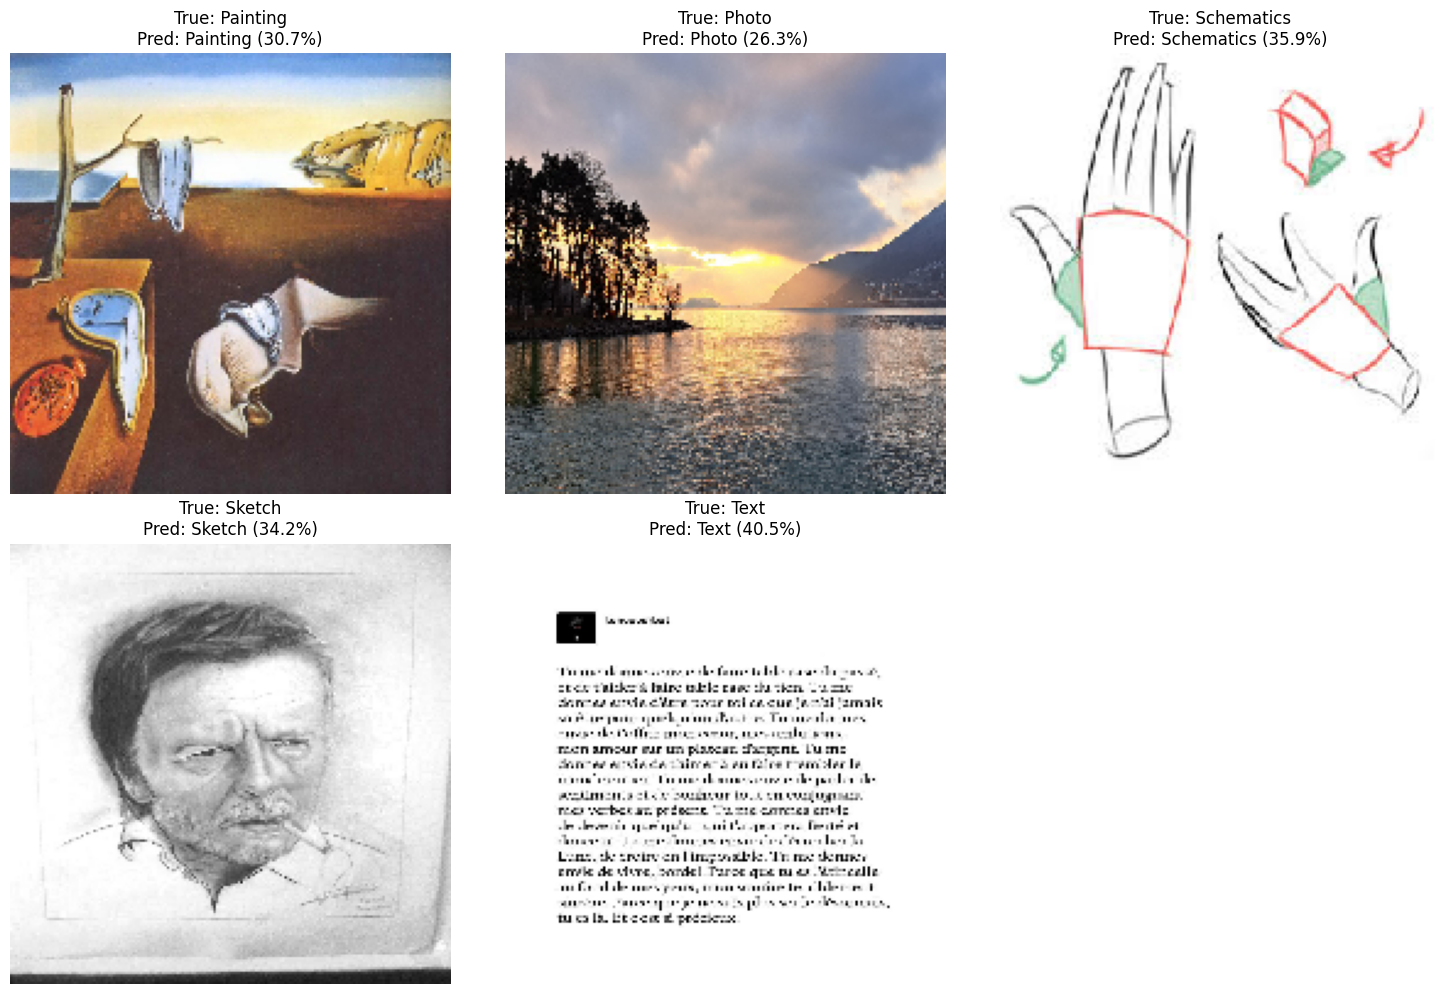

In [43]:
model = load_model('L1_model.keras')

# Ton dico d'images
image_paths = {
    'Painting': 'data_validation/peinture.jpg',
    'Photo': 'data_validation/photo.jpg',
    'Schematics': 'data_validation/schema.jpg',
    'Sketch': 'data_validation/sketch.jpg',
    'Text': 'data_validation/text.jpg'
}

plt.figure(figsize=(15, 10))

img_index = 1
for label, path in image_paths.items():
    print(f"\n--- Testing image for class '{label}' ---")

    img = tf.keras.utils.load_img(path, target_size=(180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Batch dimension

    predictions = model.predict(img_array)
    scores = tf.nn.softmax(predictions[0])

    predicted_label = CLASS_NAMES[np.argmax(scores)]
    confidence = 100 * np.max(scores)

    for i, score in enumerate(scores):
        print(f"{CLASS_NAMES[i]}: {100 * score:.2f}%")

    # Plot image dans le bon subplot
    plt.subplot(2, 3, img_index)
    plt.imshow(np.array(img).astype("uint8"))
    plt.axis("off")
    plt.title(f"True: {label}\nPred: {predicted_label} ({confidence:.1f}%)")

    img_index += 1  # incrémenter le compteur

plt.tight_layout()
plt.show()

In [ ]:
arr = np.array([10, 25, 3, 56, 42])
max_index = np.argmax(arr)
print(max_index)

In [ ]:
import random

# Display 5 images randomly of the filtered dataset
# Ensure there are enough images to display
num_samples = min(5, len(filtered_ds))
random_indices = random.sample(range(len(filtered_ds)), num_samples)
print(random_indices)

for idx in random_indices:
    plt.imshow(filtered_ds[idx])
    plt.axis('off')
    plt.show()

## Utilisation du pipeline et affichage des résultats

In [ ]:
# Visualisation d'un échantillon d'images et de leurs légendes
for images, captions in pipeline.take(1):
    num_samples = min(5, images.shape[0])
    plt.figure(figsize=(15, 8))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(captions[i].numpy().decode())
        plt.axis("off")
    plt.show()